## Student Performance Indicator

Life cycle of a machine learning project

- Understanding the problem statement
- Data Collection
- Data Checks to perform
- Exploratory Data analysis
- Data Pre-processing
- Model Training
- Choose Best model


### Problem Statement
- This project understands how the student's performance (test scores) is affected by other variables such as parent level of education, Lunch and Test preparation course, Gender, Ethinicty

### Data Collection
- You can collect data from API, Web scraping, Database of company, it could be real time data which needs to b updated in the database at a given time daily or schedule it using task scheduler and append the new data



### Import Data and required packages
Import Pandas, Numpy, Matplotlib, seaborn, Wranings Library

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Import the CSV data as Pandas Dataframe

In [2]:
df=pd.read_csv('data/stud.csv')
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


### Check the Shape, missing data, duplicates, statistics, unique categories, value counts and perform EDA

In [4]:
print(df.shape)
print(df.isnull().sum())
df.info()


(1000, 8)
gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [7]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


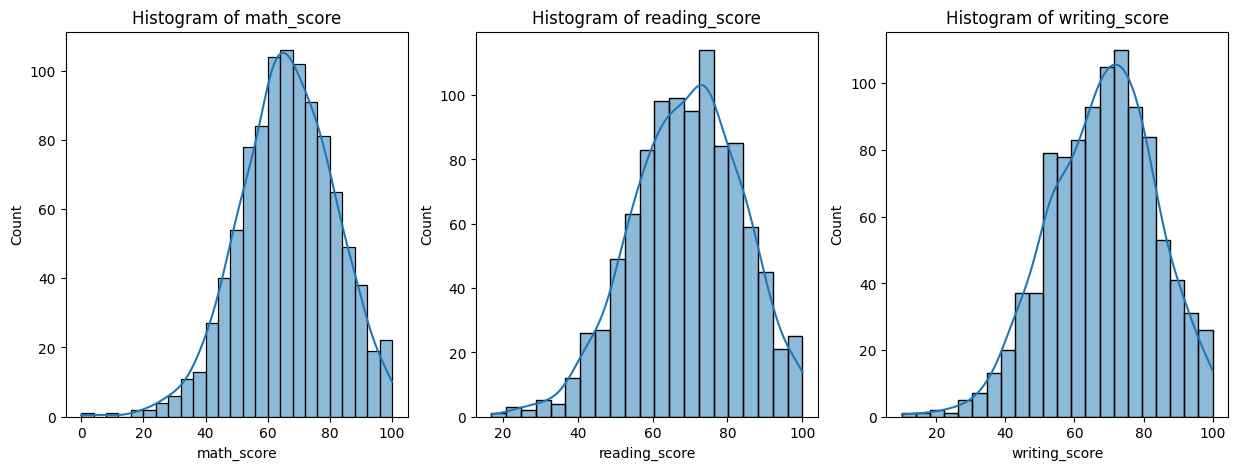

In [9]:
# Plot the histogram of these numerical columns in one figure
numerical_cols = ['math_score', 'reading_score', 'writing_score']
plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, 3, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram of {col}')    

In [13]:
# Print the categories of these categorical columns
print("Categories in gender column:", df['gender'].unique())
print("Categories in race/ethinicity",df['race_ethnicity'].unique())
print("Categories in parental level of education", df['parental_level_of_education'].unique())
print("Categories in lunch variable",df['lunch'].unique())
print("Categories in test preparation course",df['test_preparation_course'].unique())


Categories in gender column: <StringArray>
['female', 'male']
Length: 2, dtype: str
Categories in race/ethinicity <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
Categories in parental level of education <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
Categories in lunch variable <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
Categories in test preparation course <StringArray>
['none', 'completed']
Length: 2, dtype: str


In [20]:
numerical_cols=list(df.select_dtypes(include=['number']).columns)
categorical_cols=list(df.select_dtypes(include=['object','string','category']).columns)

#Print columns
print('We have {} numerical features: {}'.format(len(numerical_cols),numerical_cols))
print('we have {} categorical features: {}'.format(len(categorical_cols),categorical_cols))

We have 3 numerical features: ['math_score', 'reading_score', 'writing_score']
we have 5 categorical features: ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


In [21]:
# Add new feature of total_score and avg_score
df['total_score']=df['math_score']+df['writing_score']+df['reading_score']
df['avg_score']=df['total_score']/3
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,avg_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [26]:
full_reading=df[df['reading_score']==100]['avg_score'].count()
full_maths=df[df['math_score']==100]['avg_score'].count()
full_writing=df[df['writing_score']==100]['avg_score'].count()
full_reading,full_maths,full_writing

(np.int64(17), np.int64(7), np.int64(14))

In [36]:
# Calculate percentile of marks
percentiles = [0,1,5,10, 25, 50, 75, 100]
percentile_values = np.percentile(df['avg_score'], percentiles)
for p, value in zip(percentiles, percentile_values):
    print(f"{p}th percentile: {value}")

0th percentile: 9.0
1th percentile: 30.66
5th percentile: 44.65
10th percentile: 49.63333333333333
25th percentile: 58.333333333333336
50th percentile: 68.33333333333333
75th percentile: 77.66666666666667
100th percentile: 100.0


In [35]:
# Find no. of students with min. marks
min_reading_marks=df[df['reading_score']<=np.percentile(df['reading_score'], 1)]['avg_score'].count()
min_maths_marks=df[df['math_score']<=np.percentile(df['math_score'], 1)]['avg_score'].count()
min_writing_marks=df[df['writing_score']<=np.percentile(df['writing_score'], 1)]['avg_score'].count()
min_reading_marks,min_maths_marks,min_writing_marks

(np.int64(10), np.int64(10), np.int64(10))

In [43]:
df.columns

Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score', 'total_score', 'avg_score'],
      dtype='str')

In [46]:
print(df['gender'].value_counts())
print(df['lunch'].value_counts())
print(df['race_ethnicity'].value_counts())

gender
female    518
male      482
Name: count, dtype: int64
lunch
standard        645
free/reduced    355
Name: count, dtype: int64
race_ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64


<Axes: xlabel='avg_score', ylabel='Count'>

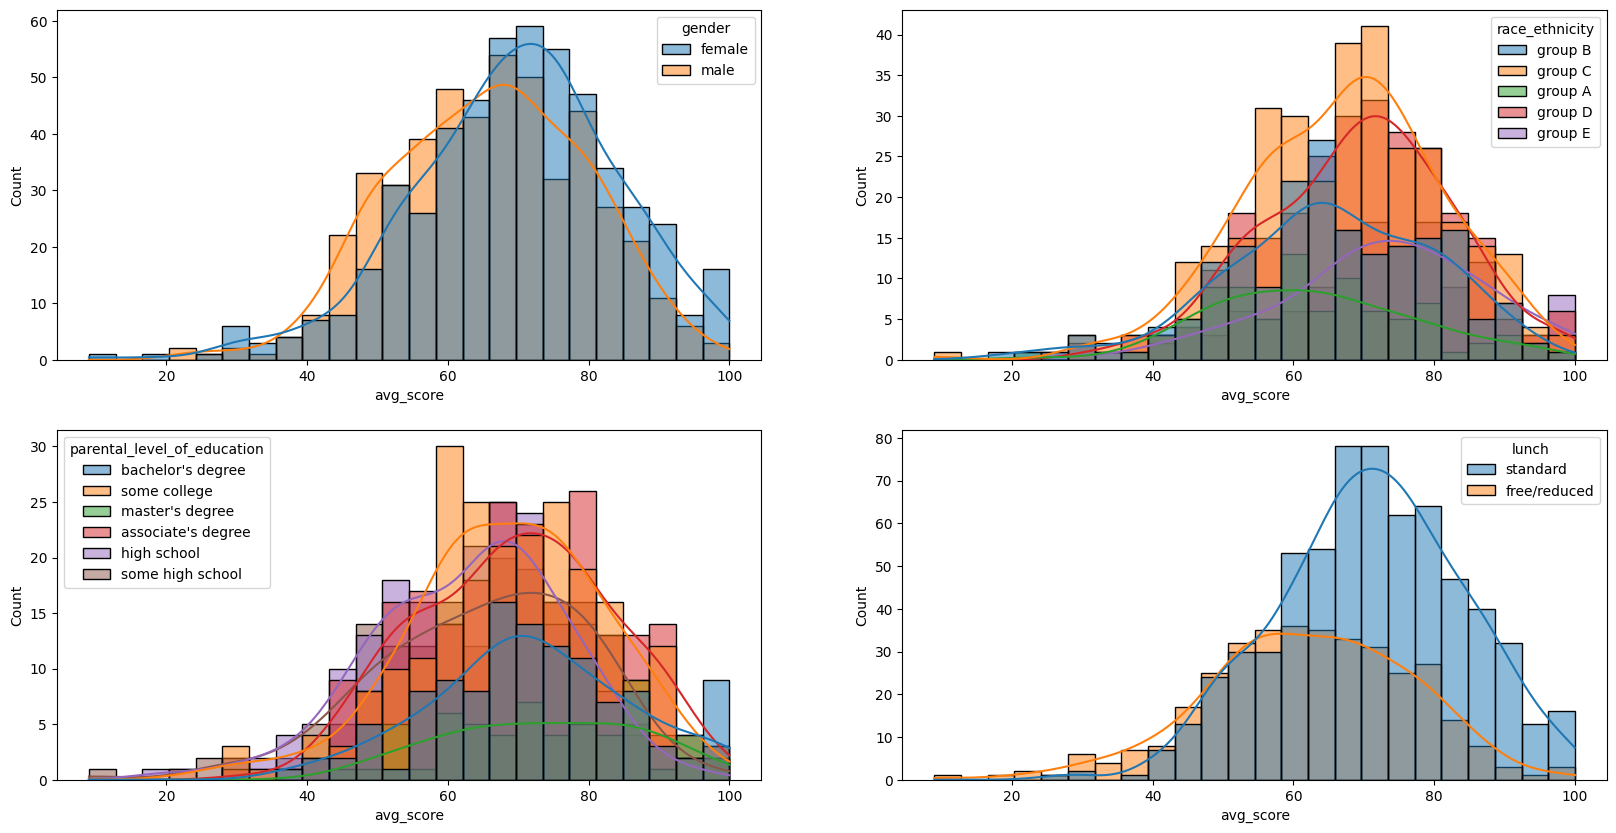

In [47]:
# Histograms 
plt.figure(figsize=(20,10))
plt.subplot(2,2,1)
sns.histplot(data=df,x='avg_score',kde=True,hue='gender')

plt.subplot(2,2,2)
sns.histplot(data=df,x='avg_score',hue='race_ethnicity',kde=True,alpha=0.5)

plt.subplot(2,2,3)
sns.histplot(data=df,x='avg_score',hue='parental_level_of_education',kde=True,alpha=0.5)

plt.subplot(2,2,4)
sns.histplot(data=df,x='avg_score',hue='lunch',kde=True,alpha=0.5)




### Insights:
- Females generally perform better than male counterparts.
- Group A and Group B achieve less scores than other race/ethnicity.
- Parental education do not impact much on test scores of students.
- Students who receive standard lunch fare better than those who receive free or reduced lunch.

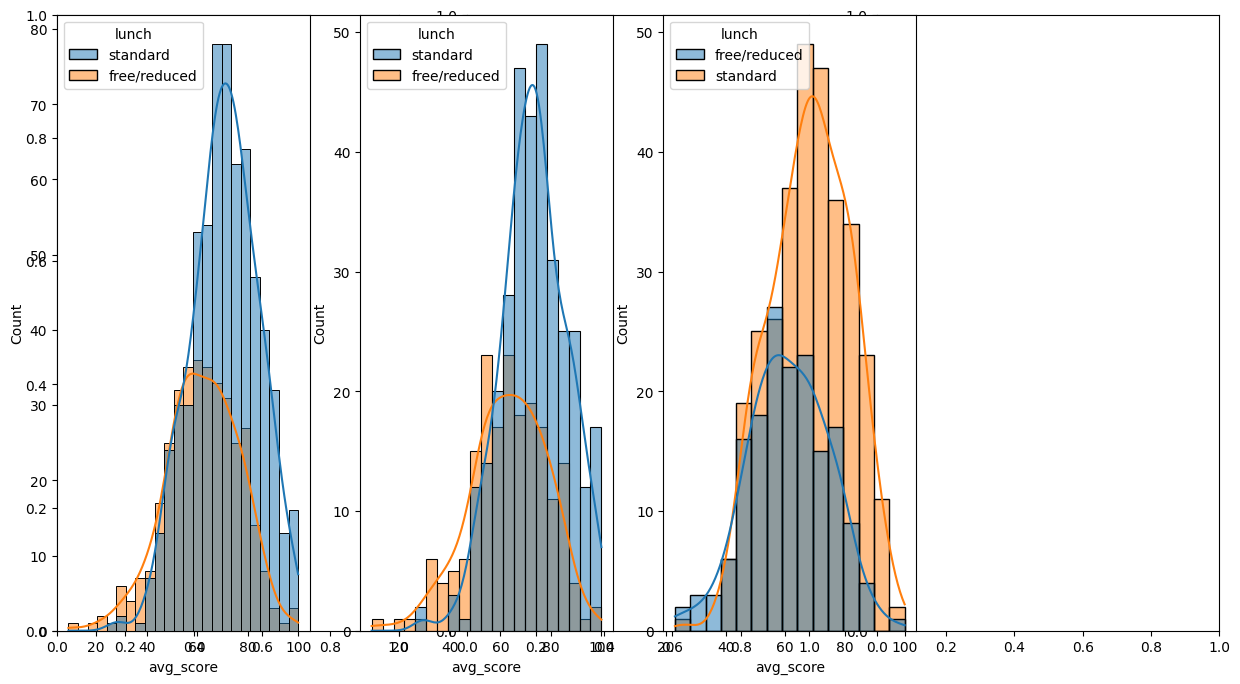

In [53]:
plt.subplots(1,3,figsize=(15,8))
plt.subplot(141)
sns.histplot(data=df,x='avg_score',kde=True,hue='lunch')
plt.subplot(142)
sns.histplot(data=df[df.gender=='female'],x='avg_score',kde=True,hue='lunch')
plt.subplot(143)
sns.histplot(data=df[df.gender=='male'],x='avg_score',kde=True,hue='lunch')
plt.show()

### Insights
- Students who recieve standard lunch perform better in test irrespective of Gender

In [58]:
df['test_preparation_course'].value_counts()

test_preparation_course
none         642
completed    358
Name: count, dtype: int64

<Axes: xlabel='avg_score', ylabel='Count'>

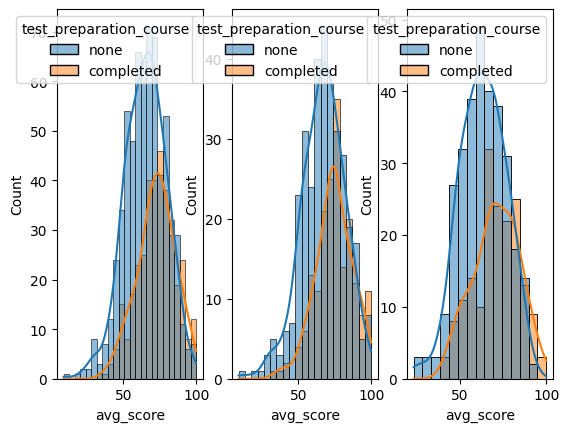

In [57]:
plt.subplot(1,3,1)
sns.histplot(data=df,x='avg_score',hue='test_preparation_course',kde=True)

plt.subplot(1,3,2)
sns.histplot(data=df[df['gender']=='female'],x='avg_score',hue='test_preparation_course',kde=True)

plt.subplot(1,3,3)
sns.histplot(data=df[df['gender']=='male'],x='avg_score',hue='test_preparation_course',kde=True)


### Insights
- Students who have completed the test preparation perform marginally better than those who have not completed it.

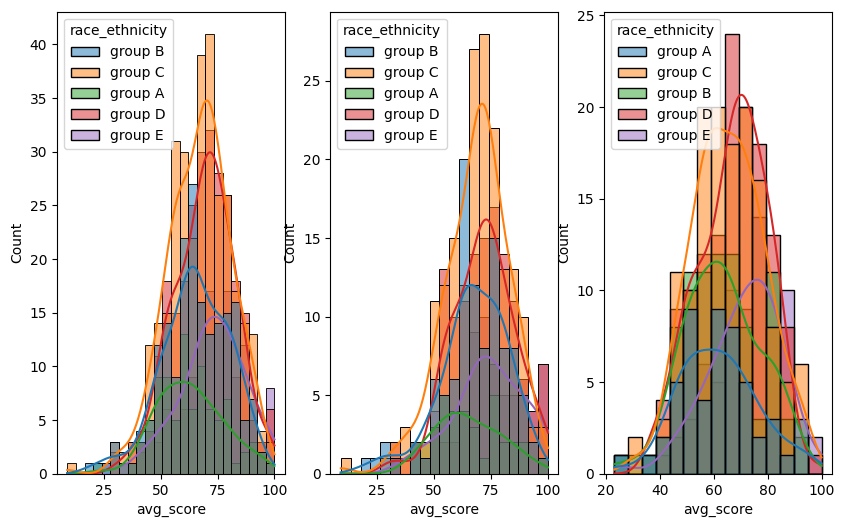

In [64]:
plt.subplots(1,3,figsize=(10,6))
plt.subplot(131)
ax =sns.histplot(data=df,x='avg_score',kde=True,hue='race_ethnicity')
plt.subplot(132)
ax =sns.histplot(data=df[df.gender=='female'],x='avg_score',kde=True,hue='race_ethnicity')
plt.subplot(133)
ax =sns.histplot(data=df[df.gender=='male'],x='avg_score',kde=True,hue='race_ethnicity')
plt.show()

### Insights
- Group E students perform better overall and irrespective of gender
- Group A  and Group B race students score less overall and irrespective of gender.


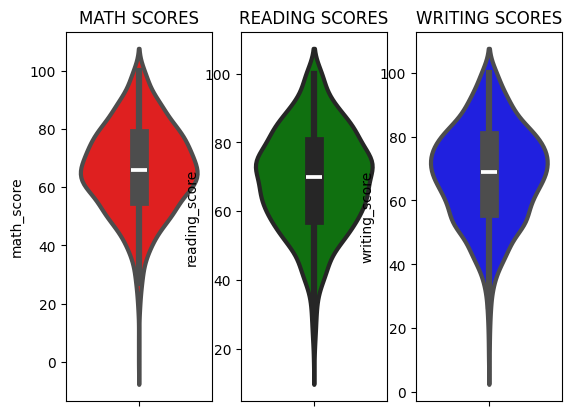

In [66]:
plt.subplot(1, 3, 1)
plt.title('MATH SCORES')
sns.violinplot(y='math_score',data=df,color='red',linewidth=3)
plt.subplot(1, 3, 2)
plt.title('READING SCORES')
sns.violinplot(y='reading_score',data=df,color='green',linewidth=3)
plt.subplot(1, 3, 3)
plt.title('WRITING SCORES')
sns.violinplot(y='writing_score',data=df,color='blue',linewidth=3)
plt.show()

### Insights
- Maths scores are between 60 and 80 and have long tail below.
- Reading scores are between 50 and 80 and have long tails below.
- Writing scores are between 50 and 80 and have long tails below.

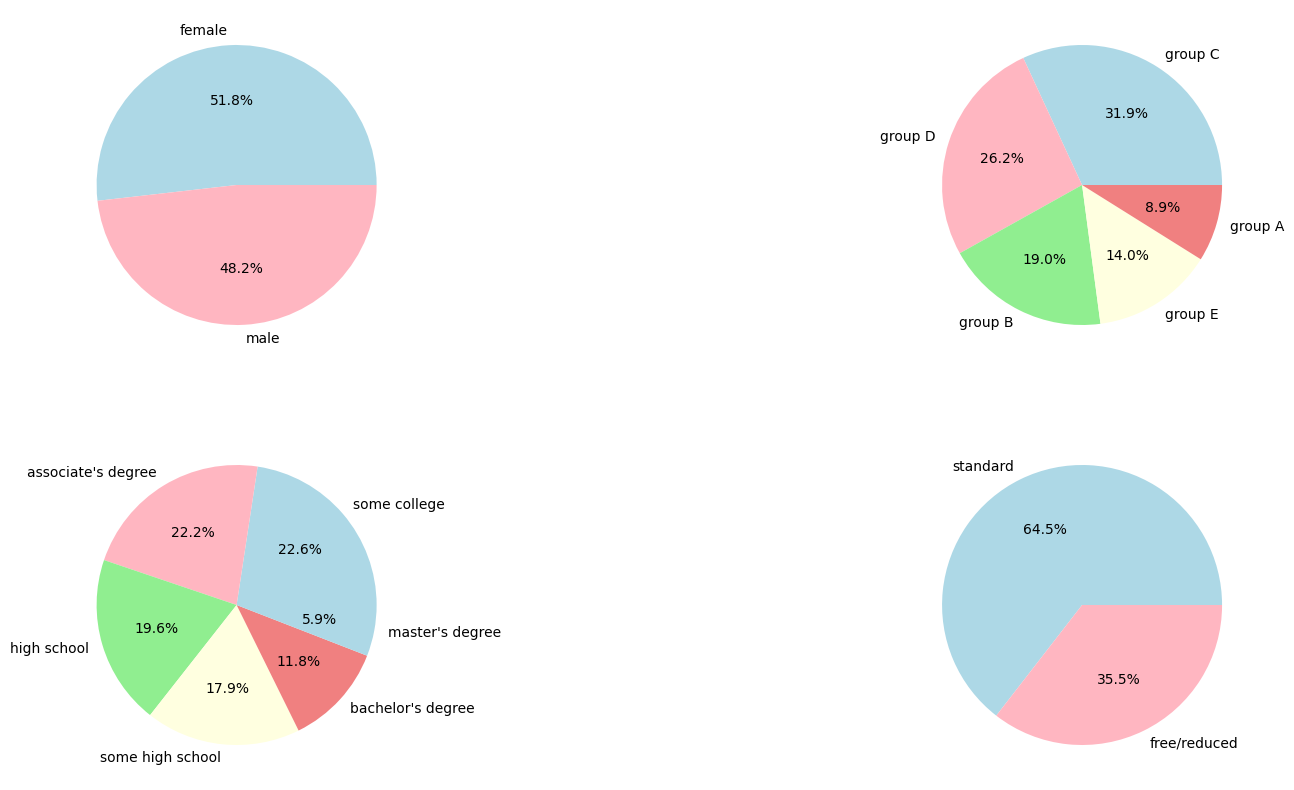

In [67]:
# Multivariate analysis using pieplot
plt.figure(figsize=(20,10))
plt.subplot(2,2,1)
df['gender'].value_counts().plot.pie(autopct='%1.1f%%',colors=['lightblue','lightpink'])
plt.subplot(2,2,2)
df['race_ethnicity'].value_counts().plot.pie(autopct='%1.1f%%',colors=['lightblue','lightpink','lightgreen','lightyellow','lightcoral'])
plt.subplot(2,2,3)
df['parental_level_of_education'].value_counts().plot.pie(autopct='%1.1f%%',colors=['lightblue','lightpink','lightgreen','lightyellow','lightcoral'])
plt.subplot(2,2,4)
df['lunch'].value_counts().plot.pie(autopct='%1.1f%%',colors=['lightblue','lightpink'])
plt.show()

### Insights
- Females and males are equal in proportion.
- Group A students are in minority and Group C students are higher in number followed by Group B.
- Mostly parents have associate degree or some college, very few parents have master's degree
- More than one third students are not receiving standard food

<Axes: xlabel='gender'>

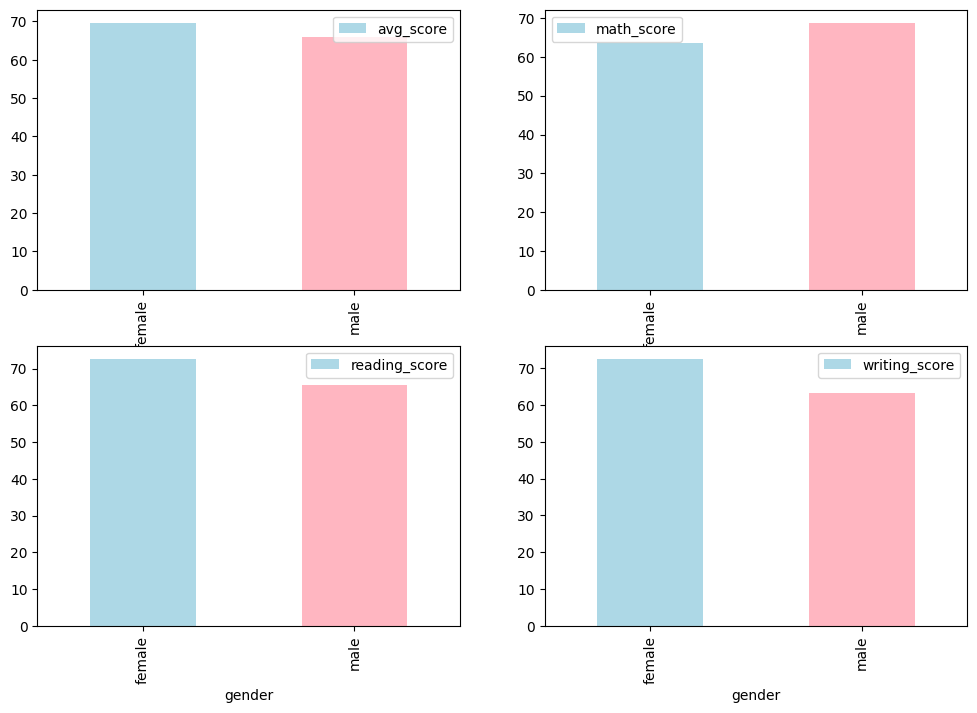

In [82]:
# BIVARIATE ANALYSIS ( Is gender has any impact on student's performance ? ) using group by

gender_grouped=df.groupby('gender')[[ 'avg_score','math_score','reading_score','writing_score','total_score']].mean().reset_index()


fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plt.subplot(2,2,1)
gender_grouped.plot.bar(x='gender',y='avg_score',color=['lightblue','lightpink'],ax=axes[0, 0])

plt.subplot(2,2,2)
gender_grouped.plot.bar(x='gender',y='math_score',color=['lightblue','lightpink'],ax=axes[0, 1])

plt.subplot(2,2,3)
gender_grouped.plot.bar(x='gender',y='reading_score',color=['lightblue','lightpink'],ax=axes[1, 0])

plt.subplot(2,2,4)
gender_grouped.plot.bar(x='gender',y='writing_score',color=['lightblue','lightpink'],ax=axes[1, 1])



### Insights
- Females score higher than male except in maths

<Axes: xlabel='race_ethnicity'>

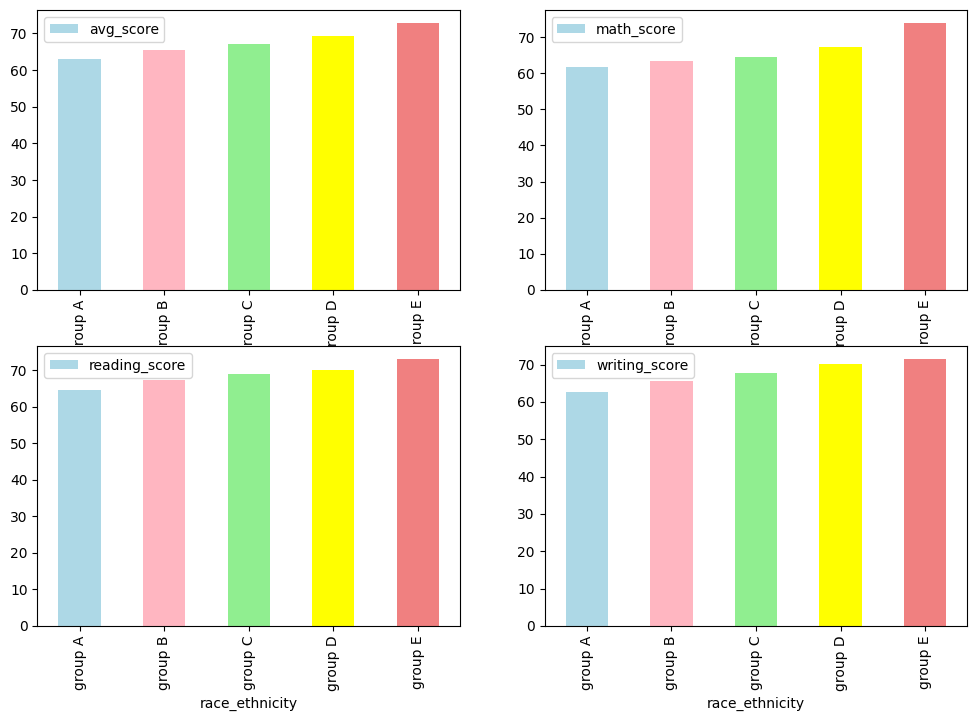

In [96]:
# BIVARIATE ANALYSIS ( Is Race/Ehnicity has any impact on student's performance ? )
race_grouped=df.groupby('race_ethnicity')[[ 'avg_score','math_score','reading_score','writing_score','total_score']].mean().reset_index()
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

plt.subplot(2,2,1)
race_grouped.plot.bar(x='race_ethnicity',y='avg_score',color=['lightblue','lightpink','lightgreen','yellow','lightcoral'],ax=axes[0, 0])   

plt.subplot(2,2,2)
race_grouped.plot.bar(x='race_ethnicity',y='math_score',color=['lightblue','lightpink','lightgreen','yellow','lightcoral'],ax=axes[0, 1])      

plt.subplot(2,2,3)
race_grouped.plot.bar(x='race_ethnicity',y='reading_score',color=['lightblue','lightpink','lightgreen','yellow','lightcoral'],ax=axes[1, 0])   

plt.subplot(2,2,4)
race_grouped.plot.bar(x='race_ethnicity',y='writing_score',color=['lightblue','lightpink','lightgreen','yellow','lightcoral'],ax=axes[1, 1])   


### Insights
- Group E students receive highest score and Group B students receive least score

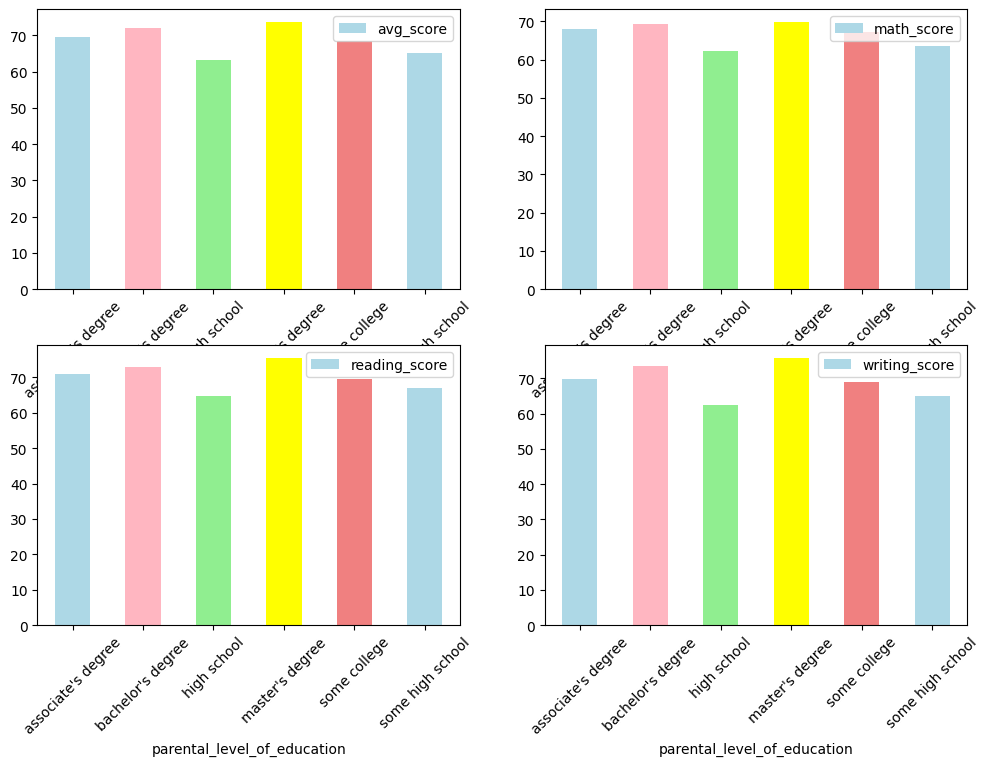

In [87]:
#BIVARIATE ANALYSIS ( Is parental education has any impact on student's performance ?

parental_grouped=df.groupby('parental_level_of_education')[[ 'avg_score','math_score','reading_score','writing_score','total_score']].mean().reset_index()
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

plt.xticks(rotation=45)
plt.subplot(2,2,1)
parental_grouped.plot.bar(x='parental_level_of_education',y='avg_score',color=['lightblue','lightpink','lightgreen','yellow','lightcoral'],ax=axes[0, 0])  

plt.xticks(rotation=45)
plt.subplot(2,2,2)
parental_grouped.plot.bar(x='parental_level_of_education',y='math_score',color=['lightblue','lightpink','lightgreen','yellow','lightcoral'],ax=axes[0, 1])

plt.xticks(rotation=45)
plt.subplot(2,2,3)
parental_grouped.plot.bar(x='parental_level_of_education',y='reading_score',color=['lightblue','lightpink','lightgreen','yellow','lightcoral'],ax=axes[1, 0])

plt.xticks(rotation=45)
plt.subplot(2,2,4)
parental_grouped.plot.bar(x='parental_level_of_education',y='writing_score',color=['lightblue','lightpink','lightgreen','yellow','lightcoral'],ax=axes[1, 1])  
plt.xticks(rotation=45)
plt.show()








### Insights
- Students whose parents have master's degree achieve highest score

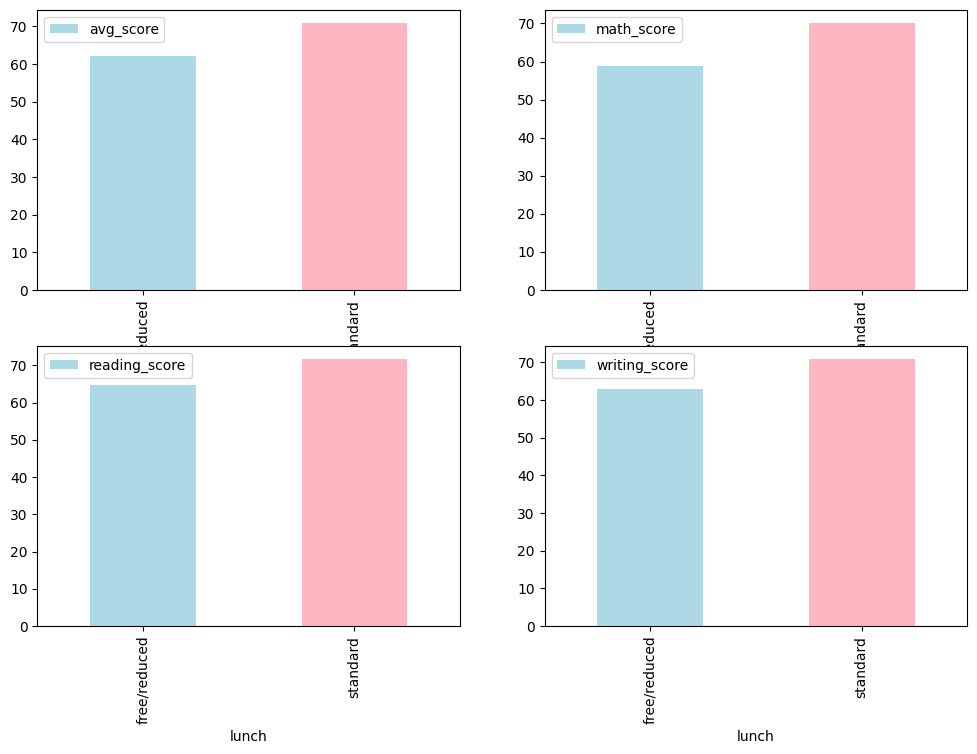

In [88]:
# BIVARIATE ANALYSIS ( Is lunch type intake has any impact on student's performance ? )
lunch_grouped=df.groupby('lunch')[[ 'avg_score','math_score','reading_score','writing_score','total_score']].mean().reset_index()
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plt.subplot(2,2,1)
lunch_grouped.plot.bar(x='lunch',y='avg_score',color=['lightblue','lightpink'],ax=axes[0, 0])   
plt.subplot(2,2,2)
lunch_grouped.plot.bar(x='lunch',y='math_score',color=['lightblue','lightpink'],ax=axes[0, 1])
plt.subplot(2,2,3)
lunch_grouped.plot.bar(x='lunch',y='reading_score',color=['lightblue','lightpink'],ax=axes[1, 0])
plt.subplot(2,2,4)
lunch_grouped.plot.bar(x='lunch',y='writing_score',color=['lightblue','lightpink'],ax=axes[1, 1])
plt.show()

### Insights
- Students who received standard meals perform better

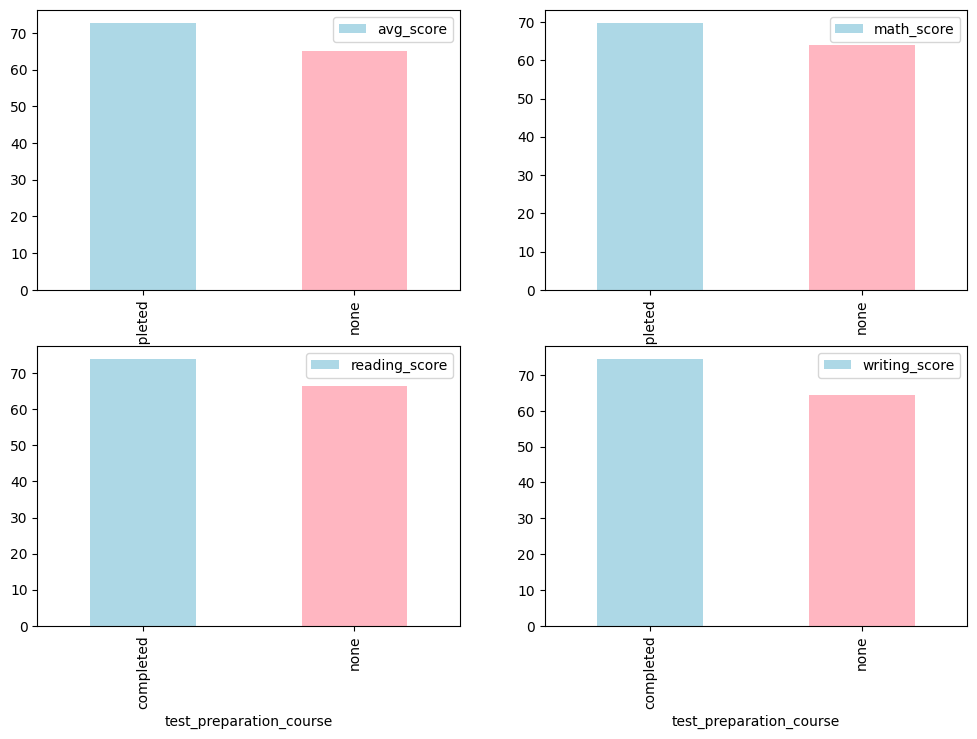

In [89]:
# BIVARIATE ANALYSIS ( Is Test prepration course has any impact on student's performance ? 
test_prep_grouped=df.groupby('test_preparation_course')[[ 'avg_score','math_score','reading_score','writing_score','total_score']].mean().reset_index()
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plt.subplot(2,2,1)
test_prep_grouped.plot.bar(x='test_preparation_course',y='avg_score',color=['lightblue','lightpink'],ax=axes[0, 0])
plt.subplot(2,2,2)
test_prep_grouped.plot.bar(x='test_preparation_course',y='math_score',color=['lightblue','lightpink'],ax=axes[0, 1])
plt.subplot(2,2,3)  
test_prep_grouped.plot.bar(x='test_preparation_course',y='reading_score',color=['lightblue','lightpink'],ax=axes[1, 0])
plt.subplot(2,2,4)
test_prep_grouped.plot.bar(x='test_preparation_course',y='writing_score',color=['lightblue','lightpink'],ax=axes[1, 1])
plt.show()                  

### Insights
- Completion of Test preparation helps achieve higher score

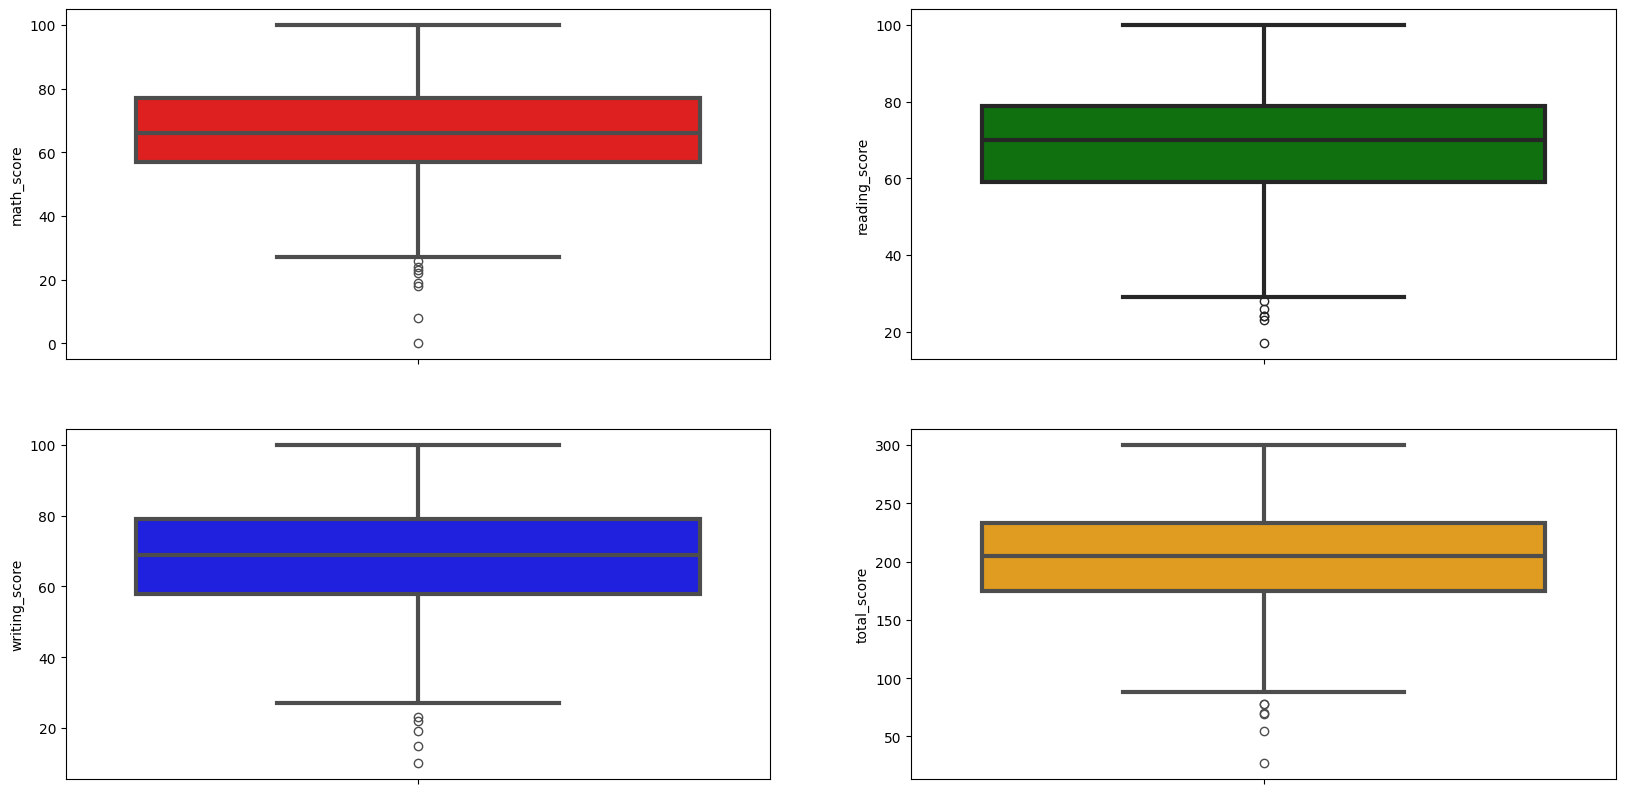

In [91]:
# CHECKING OUTLIERS
plt.figure(figsize=(20,10))
plt.subplot(2,2,1)
sns.boxplot(y='math_score',data=df,color='red',linewidth=3)
plt.subplot(2,2,2)
sns.boxplot(y='reading_score',data=df,color='green',linewidth=3)
plt.subplot(2,2,3)
sns.boxplot(y='writing_score',data=df,color='blue',linewidth=3)
plt.subplot(2,2,4)
sns.boxplot(y='total_score',data=df,color='orange',linewidth=3)
plt.show()

### Insights
- Most of the data have outliers with numbers below lower whiskers

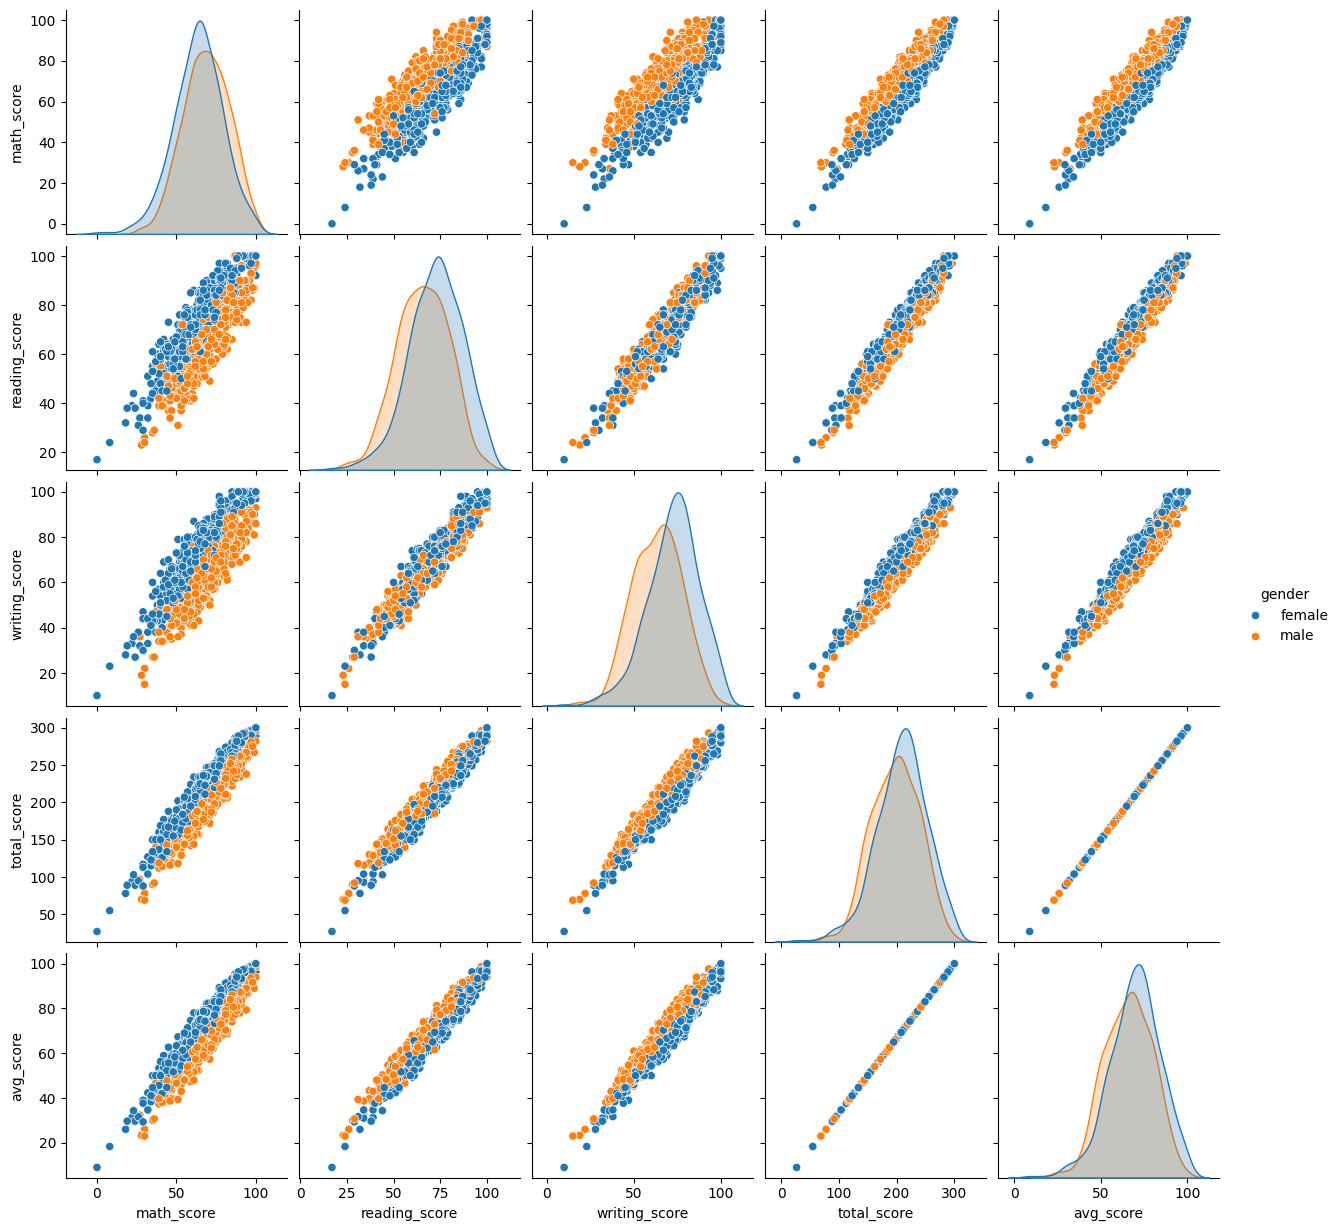

In [94]:
# Multivariate analysis using pairplot

sns.pairplot(df,hue='gender')
plt.show()

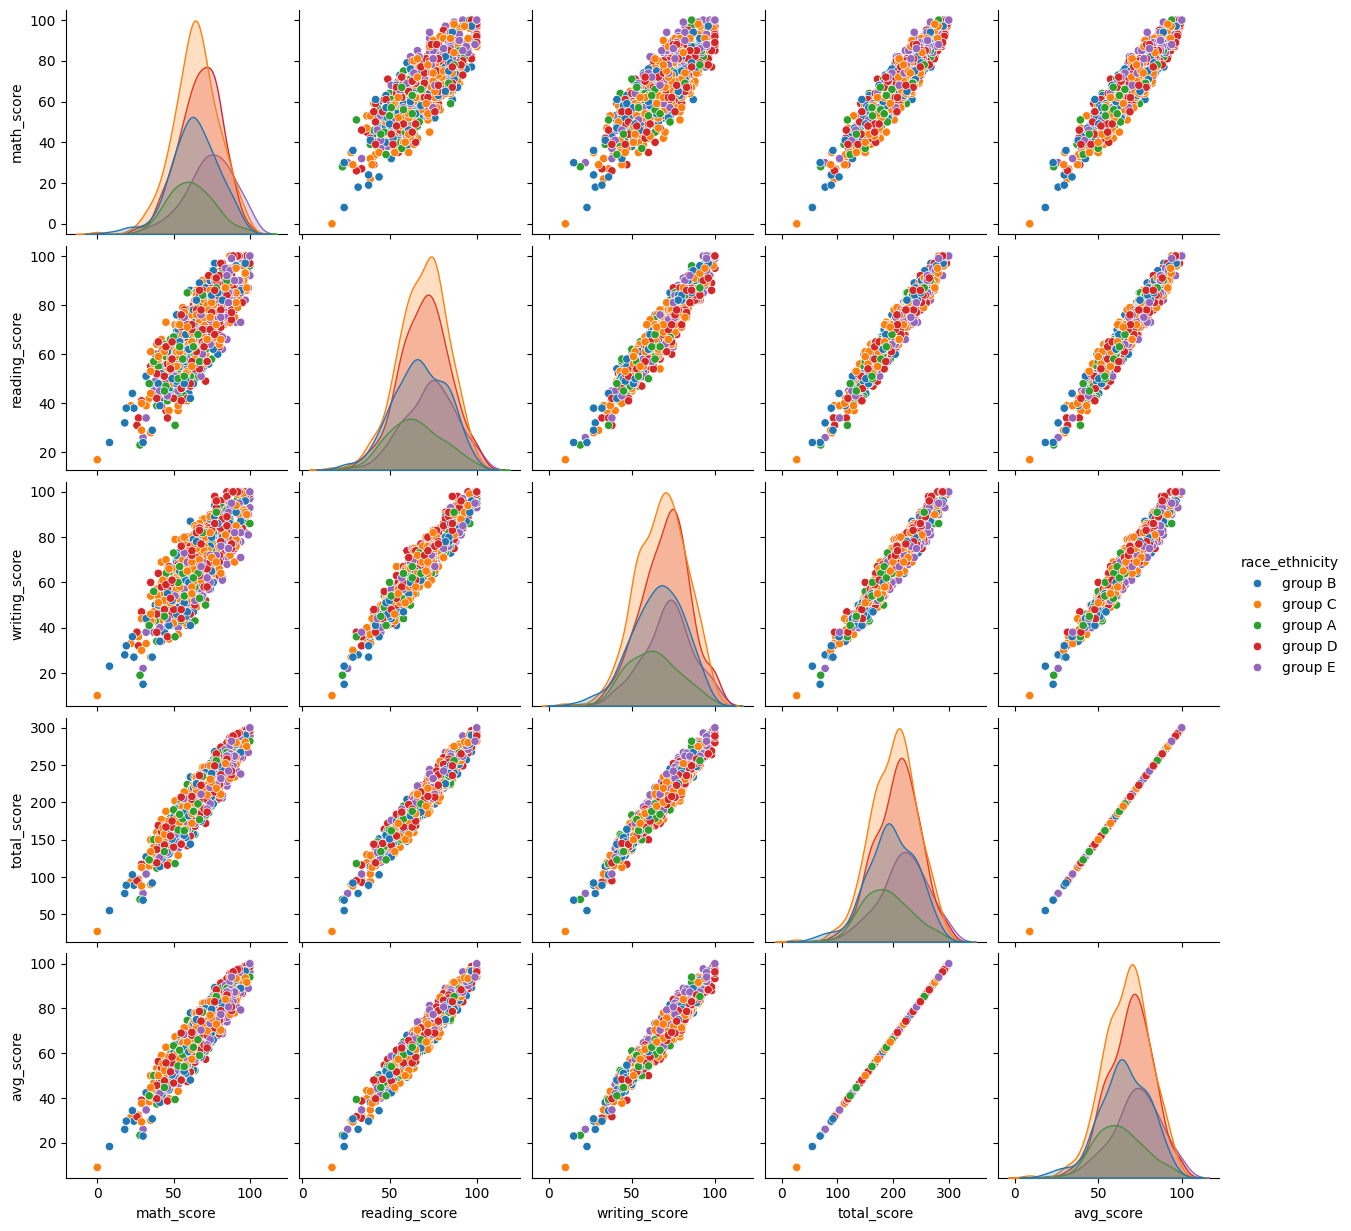

In [95]:
sns.pairplot(df,hue='race_ethnicity')